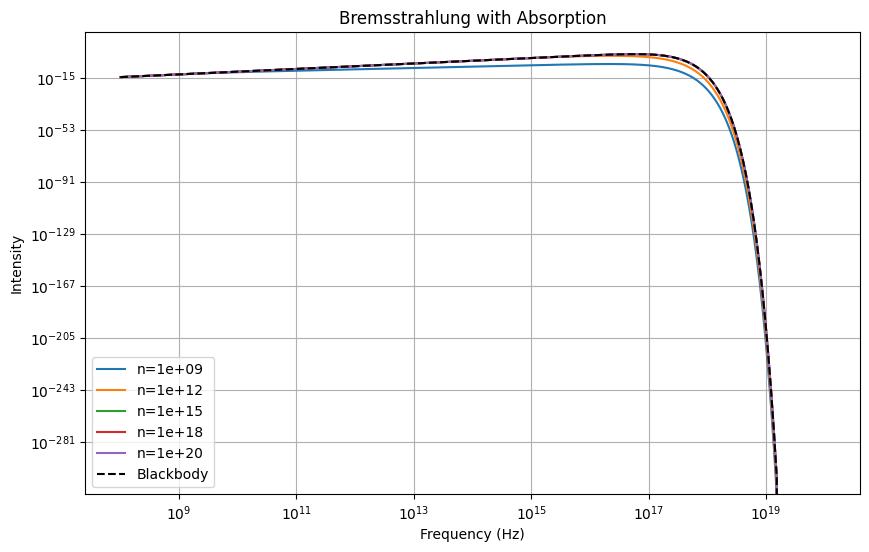

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constants (cgs)
h = 6.626e-27
k = 1.38e-16
c = 3e10

# Parameters
T = 1e6   # temperature (K)
L = 1e17  # cm

# Frequency range
nu = np.logspace(8, 20, 500)

# Safe Planck function
def B_nu(nu, T):
    x = h*nu/(k*T)
    
    # Avoid overflow
    B = np.zeros_like(nu)
    
    # For small x → normal formula
    mask1 = x < 100
    B[mask1] = (2*h*nu[mask1]**3 / c**2) / (np.exp(x[mask1]) - 1)
    
    # For large x → Wien approximation
    mask2 = x >= 100
    B[mask2] = (2*h*nu[mask2]**3 / c**2) * np.exp(-x[mask2])
    
    return B

# Free-free emissivity (scaled)
def j_nu(n, nu):
    return n**2 * T**(-0.5) * np.exp(-h*nu/(k*T))

# Absorption coefficient (scaled)
def alpha_nu(n, nu):
    return n**2 * T**(-1.5) * nu**(-2) * (1 - np.exp(-h*nu/(k*T)))

# Densities
densities = [1e9, 1e12, 1e15, 1e18, 1e20]

plt.figure(figsize=(10,6))

for n in densities:
    j = j_nu(n, nu)
    alpha = alpha_nu(n, nu)

    tau = alpha * L
    B = B_nu(nu, T)

    # Radiative transfer solution
    I = B * (1 - np.exp(-tau))

    plt.loglog(nu, I, label=f"n={n:.0e}")

# Blackbody
plt.loglog(nu, B_nu(nu, T), 'k--', label="Blackbody")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Intensity")
plt.legend()
plt.title("Bremsstrahlung with Absorption")
plt.grid()
plt.show()

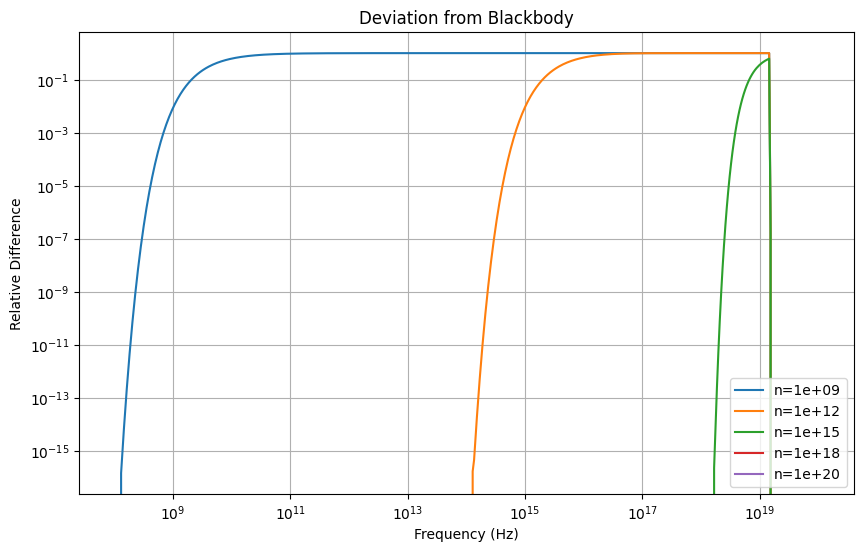

In [2]:
plt.figure(figsize=(10,6))

# Compute blackbody ONCE
B = B_nu(nu, T)

for n in densities:
    alpha = alpha_nu(n, nu)
    tau = alpha * L

    I = B * (1 - np.exp(-tau))

    # Avoid division by zero
    diff = np.abs(I - B) / (B + 1e-300)

    plt.loglog(nu, diff, label=f"n={n:.0e}")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative Difference")
plt.legend()
plt.title("Deviation from Blackbody")
plt.grid()
plt.show()